In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *

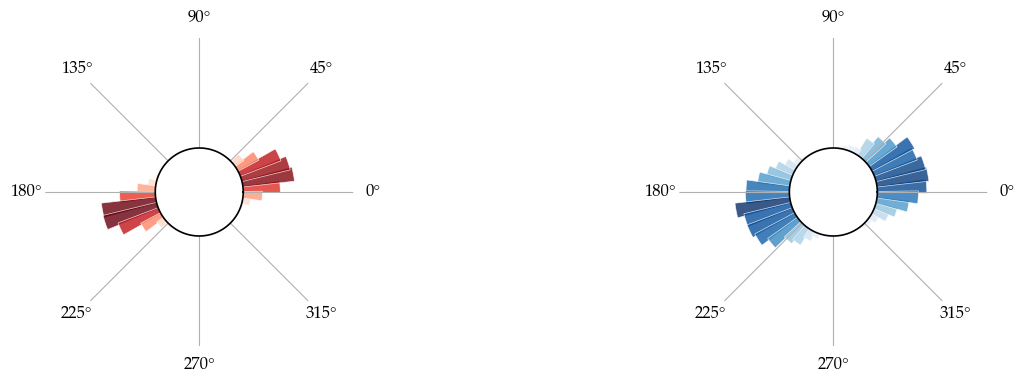

In [62]:
manifold_type = 'S1' ; manifold = get_manifold(manifold_type)
n_samples = 5000
# prior param
num_modes = 2; tau2 = 0.05; sigma2 = .15
# num_modes = 3; tau2 = 0.05; sigma2 = .15
G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 
# get data
Theta = G(n_samples)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
# display data
if True:
    fig, axs = plt.subplots(1, 2, figsize=(15, 4), subplot_kw={'polar': True}, sharey=True)
    for ax, data, color in zip(axs, [Theta, X], ['Reds', 'Blues']):
        ax.set_ylim(0,1)
        S1_histogram(data, 50, ax, color, .5)


Folds: 100%|██████████| 10/10 [00:02<00:00,  3.88it/s]


5 0.1326089957635937


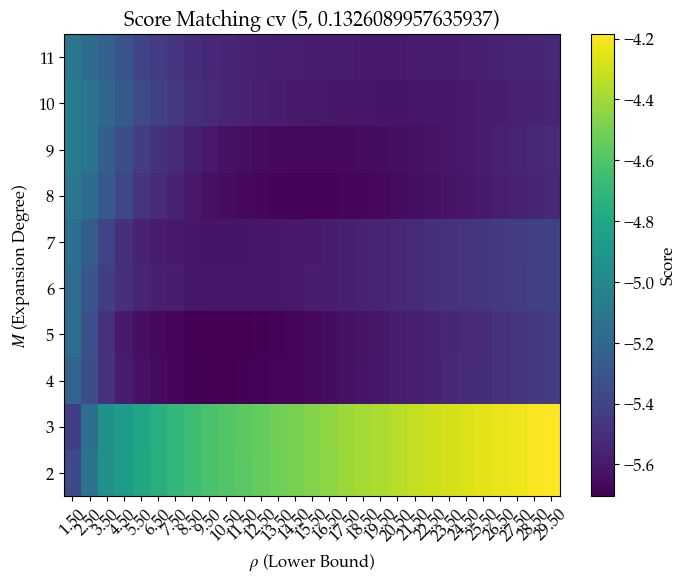

In [63]:

# crossvalidation (score matching) for parameter selection
M_grid=np.arange(2, 12)
rho_perc = np.arange(1.5,30,1)
criterion = 'cv'
params_scoreMatching , cv_scores_scoreMatching =  scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_perc, n_splits=10, return_scores=True, random_state=42)
plot_cv_scores(cv_scores_scoreMatching[criterion], M_grid, rho_perc, title=f"Score Matching cv {params_scoreMatching[criterion]}")
M,rho = params_scoreMatching[criterion]
print(M,rho)


In [64]:
# --- empirical denoiser
delta = denoiser(manifold_type, X, M, rho, sigma2, X)

# oracle denoiser
num_oracle_samples = 10000
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, n_bins = 1000, G = G)

# --- losses
loss_N = sq_loss(manifold, X, Theta)
loss_T = sq_loss(manifold, delta, Theta) 
loss_oracle_T = sq_loss(manifold, oracle_delta_T, Theta) 

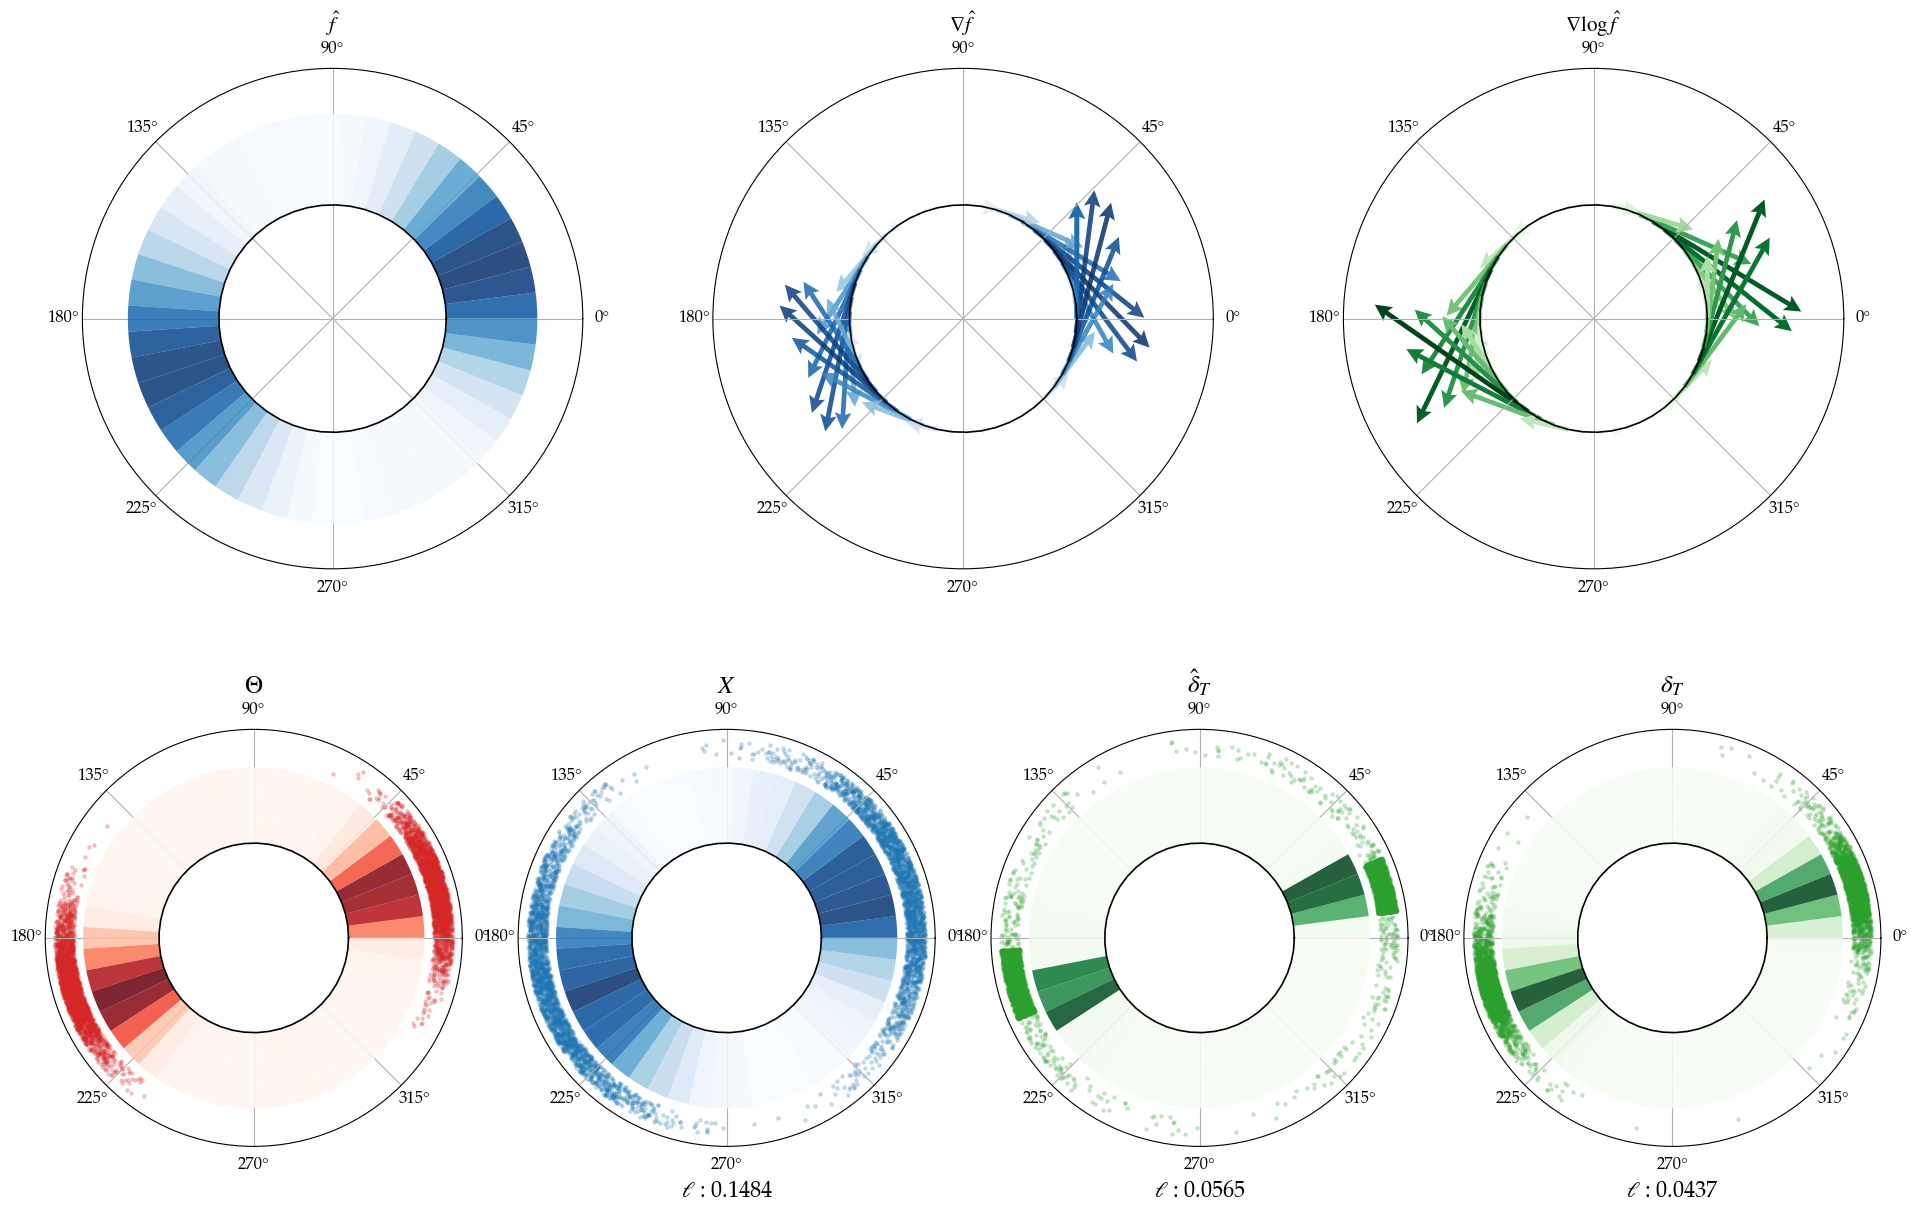

In [65]:
size = 5.5; jitter_std = 5e-2; alpha = .2
grid_size  = 50; bottom = .5; top = .9; upperlim = 1.1
first_row = True
second_row = True
if first_row or second_row:
    fig = plt.figure(figsize=(24, 14))
    gs = fig.add_gridspec(2, 12, height_ratios=[1.2, 1.0], hspace=0.35, wspace=0.25)
# ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
if first_row:
    # Row 1: 3 larger polar plots (each spans 4/12 columns)
    axs_top = [fig.add_subplot(gs[0, 0:4], projection='polar'),
            fig.add_subplot(gs[0, 4:8], projection='polar'),
            fig.add_subplot(gs[0, 8:12], projection='polar')]

    grid_I = np.linspace(0, 2*np.pi, grid_size)
    grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
    _, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)
    norm_hat_f = hat_f / hat_f.max()
    # ---------- DENSITY ---------------------------------------------------------------------------
    hat_pos_f = np.maximum(hat_f, 0)    
    widths = np.diff(grid_I)  # angular width of each bin
    bars = axs_top[0].bar(
        grid_I[:-1],                        
        top - bottom,                      
        width=widths,
        bottom=bottom,                      
        color=plt.colormaps['Blues'](norm_hat_f[:-1]),
        alpha=0.85,
        edgecolor='none',
        align='edge',
        zorder=2,
        )
    axs_top[0].set_title('$\\hat f$', fontsize=15)
    # ---------- GRADIENT ---------------------------------------------------------------------------
    axs_top[1].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_grad_f[:, 0],          
        hat_grad_f[:, 1],          
        np.linalg.norm(hat_grad_f, axis=1),                 
        scale=2,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Blues',       
        alpha=0.85,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs_top[1].set_title('$\\nabla \hat f$', fontsize=15)
    # ---------- SCORE ---------------------------------------------------------------------------
    hat_score = hat_grad_f /  np.maximum(hat_f.reshape(-1, 1), rho)
    axs_top[2].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        hat_score[:, 0],          
        hat_score[:, 1],          
        np.linalg.norm(hat_score, axis=1),                 
        scale=10,           
        width=0.0095,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Greens',       
        alpha=1,         
        edgecolors=None,     
        linewidths=0.25,     
    )
    axs_top[2].set_title('$\\nabla \log \hat f$', fontsize=15)
    for ax in axs_top: 
        ax.set_ylim(0, upperlim)  
        ax.set_yticks([])
        # ax.bar(0, bottom, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
        ax.plot(grid_I, bottom*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)

# ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
if second_row:
    # Row 2: 4 polar plots (each spans 3/12 columns)
    axs_bottom = [fig.add_subplot(gs[1, 0:3], projection='polar'),
                fig.add_subplot(gs[1, 3:6], projection='polar'),
                fig.add_subplot(gs[1, 6:9], projection='polar'),
                fig.add_subplot(gs[1, 9:12], projection='polar')]
    # ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
    for ax, data,  title, loss, c, cmap in zip(axs_bottom,
                                    [Theta, X, delta, oracle_delta_T],
                                    ['$\Theta$', '$X_i$', '$\hat\delta_{\mathcal{T}}$', '$\delta_{\mathcal{T}}$', '$\delta_B$'],
                                    [None, loss_N, loss_T, loss_oracle_T],
                                    ['C3', 'C0', 'C2', 'C2', 'C4'],
                                    ['Reds', 'Blues', 'Greens', 'Greens']):  
        S1scatter(data, ax, c, alpha, size, jitter_std)

        ax.set_title(title, fontsize=18)
        
        if title != '$\Theta$':
            ax.set_xlabel(rf'$\ell$ : {loss:.4f}', fontsize=16)
            
        bin_centers = uniform_points(manifold_type, grid_size)          
        dists_all = np.array([ manifold.metric.dist(g, bin_centers) for g in data])        
        labels = np.argmin(dists_all, axis=1)                      
        hat_f = np.bincount(labels, minlength=grid_size) / len(data); hat_f /= np.max(hat_f)

        bars = ax.bar(grid_I[:-1],top - bottom, width=np.diff(grid_I),bottom=bottom,      
                color=plt.colormaps[cmap](hat_f[:-1]),alpha=0.85,edgecolor='none',align='edge',zorder=2)
        ax.set_ylim(0, upperlim)
        ax.set_yticks([])
        ax.bar(0, bottom, width=2 * np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
        ax.plot(grid_I, bottom * np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)   

    # print('Excess risk : ', loss_T - loss_oracle_T)
    fig.savefig(f"../fig/denoising_S1.png", bbox_inches='tight')

In [66]:
hat_score.shape

(50, 2)